In [60]:
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data import *
from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

In [61]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=100, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=10, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=200, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=False, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [62]:
xtrain, xtest, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

info 0 100 1
info 101 201 1


In [63]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [64]:
def kPCA(X, Y, Z, eps=1e-6):
    # Kernel matrix (B,B)
    a = X @ X.T + Y @ Y.T + Z @ Z.T
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)
    return h, s

In [65]:
# Energy function
def my_loss(output_im, data_im, output_sk, data_sk, output_la, data_la):
    h, s = kPCA(output_im, output_sk, output_la) # Latent representation and eigenvalues

    U = torch.mm(torch.t(output_im), h) # Get encoded data back from the latent representation
    V = torch.mm(torch.t(output_sk), h)
    W = torch.mm(torch.t(output_la), h)

    x_im_tilde = net_im_de(torch.mm(h, torch.t(U))) # Reconstruction of the input
    x_sk_tilde = net_sk_de(torch.mm(h, torch.t(V)))
    x_la_tilde = net_la_de(torch.mm(h, torch.t(W)))

    # cost
    f1 = torch.trace(torch.mm(torch.mm(output_im, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output_sk, V), torch.t(h))) + torch.trace(torch.mm(torch.mm(output_la, W), torch.t(h)))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))) + (torch.trace(torch.mm(torch.t(W), W))))

    recon_loss1 = torch.nn.MSELoss()
    recon_loss2 = torch.nn.MSELoss()
    recon_loss3 = torch.nn.MSELoss()
    f4 = recon_loss1(x_im_tilde.view(-1, 49152), data_im.view(-1, 49152)) + recon_loss2(x_sk_tilde.view(-1, 16384), data_sk.view(-1, 16384)) + recon_loss3(x_la_tilde.view(-1, 40), data_la.view(-1, 40))  # reconstruction loss

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + 100 * f4
    return loss

In [66]:
net_im_en = NetImEn().double().to(opt.device)
net_sk_en = NetSkEn().double().to(opt.device)
net_la_en = NetLaEn().double().to(opt.device)

net_im_de = NetImDe().double().to(opt.device)
net_sk_de = NetSkDe().double().to(opt.device)
net_la_de = NetLaDe().double().to(opt.device)

In [67]:
params = list(net_im_en.parameters()) + list(net_sk_en.parameters()) + list(net_la_en.parameters()) + list(net_im_de.parameters()) + list(net_sk_de.parameters()) + list(net_la_de.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

In [68]:
# while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
#     permutation = torch.randperm(opt.N)
#     avg_loss = 0
#     for i, (data_im, data_sk, data_la) in enumerate(xtrain):
#         # indices = permutation[i:i + mb_size]

#         data_im = data_im.to(opt.device)
#         data_sk = data_sk.to(opt.device)
#         data_la = data_la.to(opt.device)
        
#         output_im = net_im_en(data_im)
#         output_sk = net_sk_en(data_sk)
#         output_la = net_la_en(data_la)

#         loss = my_loss(output_im, data_im, output_sk, data_sk, output_la, data_la)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         avg_loss += loss.detach().cpu().numpy()
        
#     cost = avg_loss

#     # Remember lowest cost and save checkpoint
#     is_best = cost < l_cost
#     l_cost = min(cost, l_cost)
#     dirs.save_checkpoint({
#         'epochs': t + 1,
#         'net_im_en_state_dict': net_im_en.state_dict(),
#         'net_sk_en_state_dict': net_sk_en.state_dict(),
#         'net_la_en_state_dict': net_la_en.state_dict(),

#         'net_im_de_state_dict': net_im_de.state_dict(),
#         'net_sk_de_state_dict': net_sk_de.state_dict(),
#         'net_la_de_state_dict': net_la_de.state_dict(),

#         'l_cost': l_cost,
#         'optimizer': optimizer.state_dict()}, is_best)

#     print(t, cost)
#     t += 1
# print('Finished Training. Lowest cost: {}'.format(l_cost))

In [69]:
# # Get latest model
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net_im_en.load_state_dict(sd_mdl['net_im_en_state_dict'])
#     net_sk_en.load_state_dict(sd_mdl['net_sk_en_state_dict'])
#     net_la_en.load_state_dict(sd_mdl['net_la_en_state_dict'])

#     net_im_de.load_state_dict(sd_mdl['net_im_de_state_dict'])
#     net_sk_de.load_state_dict(sd_mdl['net_sk_de_state_dict'])
#     net_la_de.load_state_dict(sd_mdl['net_la_de_state_dict'])

# U, V, W, h, s = mmcelebahq_final_compute(opt, net_im_en, net_sk_en, net_la_en, kPCA)

In [70]:
# # Save Model
# torch.save({'net_im_en': net_im_en,
#             'net_sk_en': net_sk_en,
#             'net_la_en': net_la_en,

#             'net_im_de': net_im_de,
#             'net_sk_de': net_sk_de,
#             'net_la_de': net_la_de,


#             'net_im_en_state_dict': net_im_en.state_dict(),
#             'net_sk_en_state_dict': net_sk_en.state_dict(),
#             'net_la_en_state_dict': net_la_en.state_dict(),

#             'net_im_de_state_dict': net_im_de.state_dict(),
#             'net_sk_de_state_dict': net_sk_de.state_dict(),
#             'net_la_de_state_dict': net_la_de.state_dict(),

#             'data_im': data_im,
#             'data_sk': data_sk,
#             'data_la': data_la,
#             'classes': get_classes(),
#             'h': h, 'N': N, 's': s, 'U': U, 'V': V, 'W': W}, 'out/{}'.format(dirs.dirout))

In [71]:
model = torch.load('./out/5000.tar', weights_only=False)

U = model['U']
V = model['V']
W = model['W']
h = model['h']
s = model['s']

data_im = model['data_im']
data_sk = model['data_sk']
data_la = model['data_la']

net_im_en = model['net_im_en']
net_sk_en = model['net_sk_en']
net_la_en = model['net_la_en']

net_im_de = model['net_im_de']
net_sk_de = model['net_sk_de']
net_la_de = model['net_la_de']

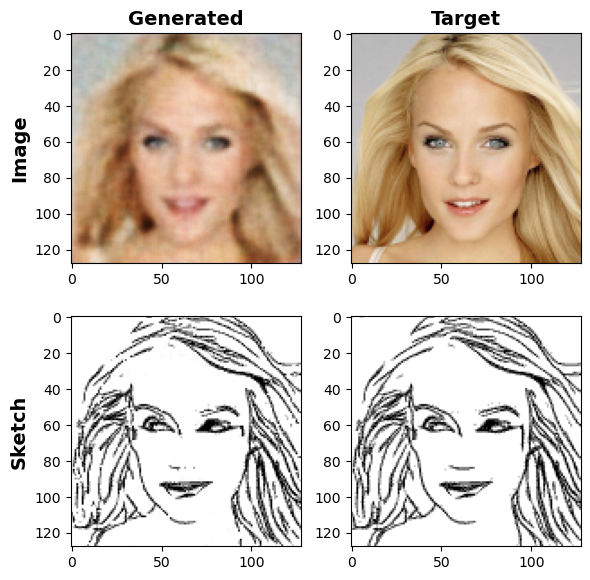

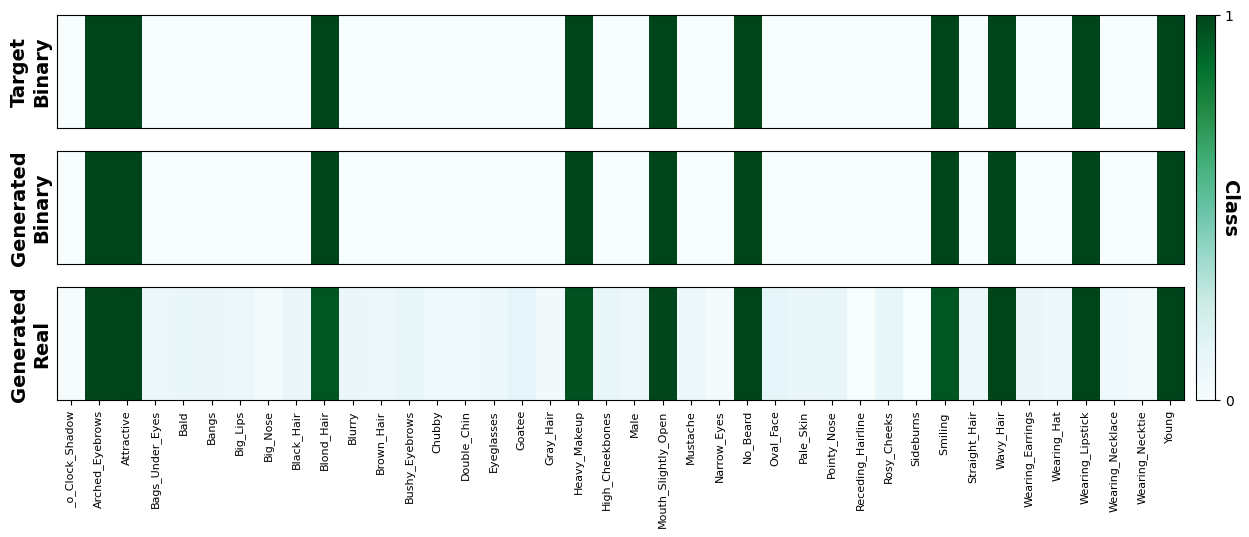

In [72]:
target_index = 1                                                                    # Sample Index
h_target = h[target_index, :]                                                       # Latent representation of the target sample

# Generate Image
z_im = torch.mv(U, h_target).unsqueeze(0)                                           # Get the encoding back from the latent representation
im_gen = net_im_de(z_im).detach().cpu().numpy()                                     # Decode using the trained models
im_gen = im_gen.reshape(3, 128, 128).transpose(1, 2, 0)                             # Reshape and reorder channels for plotting

# Generate Sketch
z_sk = torch.mv(V, h_target).unsqueeze(0)
sk_gen = net_sk_de(z_sk).detach().cpu().numpy()
sk_gen = sk_gen.reshape(128, 128).transpose(0,1)

# Generate Labels
la_gen = net_la_de(torch.mv(W, h_target)).detach().cpu().numpy()

# Plot Image + Sketch
fig, ax = plt.subplots(2, 2, figsize=(6, 6))

ax[0,0].imshow(im_gen)
ax[0,0].set_title('Generated', size=14, weight='bold')
ax[0,0].set_ylabel('Image', rotation=90, size=14, weight='bold')

ax[1,0].imshow(sk_gen, cmap='gray')
ax[1,0].set_ylabel('Sketch', rotation=90, size=14, weight='bold')

ax[0,1].imshow(data_im[target_index].numpy().transpose(1, 2, 0))
ax[0,1].set_title('Target', size=14, weight='bold')

ax[1,1].imshow(data_sk[target_index].numpy().transpose(1, 2, 0), cmap='gray')

plt.tight_layout()
plt.show()

# Plot Labels
fig, ax = plt.subplots(3, 1, figsize=(15, 5))
ax[0].imshow(data_la[target_index].numpy().reshape(1, -1), cmap='BuGn', aspect='auto')
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].set_ylabel('Target\nBinary', rotation=90, size=14, weight='bold')

ax[1].imshow((la_gen.reshape(1, -1) > 0.5).astype(np.int64), cmap='BuGn', aspect='auto')
ax[1].set_yticks([])
ax[1].set_xticks([])
ax[1].set_ylabel('Generated\nBinary', rotation=90, size=14, weight='bold')

ax[2].imshow(la_gen.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[2].set_yticks([])
ax[2].set_xticks(range(len(get_classes())))
ax[2].set_xticklabels(get_classes(), rotation=90, size=8)
ax[2].set_ylabel('Generated\nReal', rotation=90, size=14, weight='bold')

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='BuGn'), ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])
cbar.set_label('Class', rotation=270, size=14, weight='bold')

## Evaluation

In [75]:
recon_loss = torch.nn.MSELoss(reduction="mean")

net_im_en.eval()
net_sk_en.eval()
net_la_en.eval()
net_im_de.eval()
net_sk_de.eval()
net_la_de.eval()

im_loss_sum = 0.0
sk_loss_sum = 0.0
la_loss_sum = 0.0
loss_sum = 0.0
n = 0

with torch.no_grad():
    for data_im, data_sk, data_la in xtest:
        data_im = data_im.to(opt.device)
        data_sk = data_sk.to(opt.device)
        data_la = data_la.to(opt.device)

        im_tilde = net_im_de(net_im_en(data_im))
        sk_tilde = net_sk_de(net_sk_en(data_sk))
        la_tilde = net_la_de(net_la_en(data_la))

        B = data_im.size(0)

        im_loss = recon_loss(im_tilde.view(B, -1), data_im.view(B, -1))
        sk_loss = recon_loss(sk_tilde.view(B, -1), data_sk.view(B, -1))
        la_loss = recon_loss(la_tilde.view(B, -1), data_la.view(B, -1))

        im_loss_sum += im_loss.item() * B
        sk_loss_sum += sk_loss.item() * B
        la_loss_sum += la_loss.item() * B
        loss_sum += (im_loss + sk_loss + la_loss).item() * B
        n += B

test_im_loss = im_loss_sum / n
test_sk_loss = sk_loss_sum / n
test_la_loss = la_loss_sum / n
test_loss = loss_sum / n
print("Total Test Reconstruction Loss:", test_loss)
print("Image Loss: :", test_im_loss)
print("Sketch Loss`:", test_sk_loss)
print("Label Loss:", test_la_loss)

Total Test Reconstruction Loss: 0.733273997917878
Image Loss: : 0.21680238577571478
Sketch Loss`: 0.10540467029919505
Label Loss: 0.41106694184296816
